# Aprendizaje No Supervisado: K-Means y DBSCAN

Este cuaderno desarrolla dos algoritmos de clustering con datos dummy y un enfoque didactico:
- K-Means (basado en centroides)
- DBSCAN (basado en densidad)

Objetivo: entender no solo como implementarlos, sino **como evaluarlos correctamente**.


## 1. Datos dummy (sinteticos y reproducibles)

Usaremos datasets sinteticos de `scikit-learn`, ampliamente utilizados para docencia:
- `make_blobs`: clusters aproximadamente esfericos (ideal para K-Means).
- `make_moons`: estructura no convexa (util para mostrar fortaleza de DBSCAN).


## Glosario rapido (terminos clave)

- **Conjunto convexo:** una region es convexa si, al tomar cualquier par de puntos dentro de esa region, el segmento que los une queda completamente dentro de la region.
- **Cluster convexo:** grupo con forma compacta (tipo esfera/elipse en 2D) donde K-Means suele funcionar bien.
- **Cluster no convexo:** grupo con forma curva, anillo o media luna; K-Means puede fallar porque divide por cercania a centroides lineales.
- **Centroide:** promedio de las coordenadas de los puntos de un cluster.
- **Densidad (en DBSCAN):** cantidad de puntos en una vecindad de radio `eps`.
- **Ruido / outlier:** punto que DBSCAN marca como `-1` porque no alcanza la densidad minima (`min_samples`).

Referencia conceptual (convexidad, validada): Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press. DOI: https://doi.org/10.1017/CBO9780511804441


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    pairwise_distances,
)

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)


In [2]:
# Dataset A: blobs para K-Means
X_blobs, y_blobs = make_blobs(
    n_samples=700,
    centers=[(-4, -4), (0, 0), (4, 4), (0, 5)],
    cluster_std=[0.8, 1.0, 0.9, 0.7],
    random_state=42,
)

# Dataset B: moons + ruido uniforme para DBSCAN
X_moons, y_moons = make_moons(n_samples=700, noise=0.07, random_state=42)
rng = np.random.default_rng(42)
noise_points = rng.uniform(low=[-1.5, -1.0], high=[2.5, 1.5], size=(70, 2))
X_moons_noise = np.vstack([X_moons, noise_points])

print("Blobs:", X_blobs.shape)
print("Moons + ruido:", X_moons_noise.shape)


Blobs: (700, 2)
Moons + ruido: (770, 2)


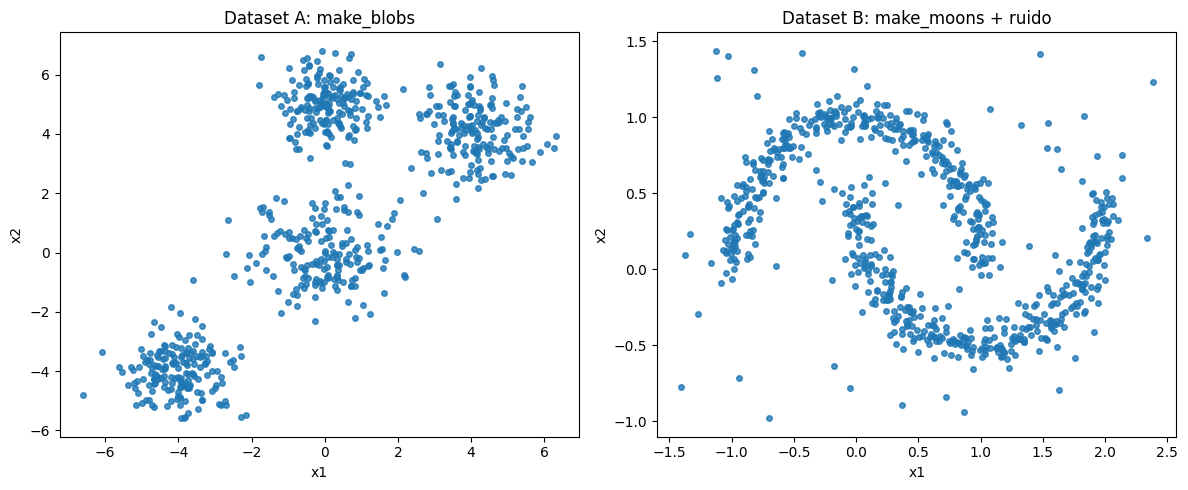

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], s=16, alpha=0.8)
axes[0].set_title("Dataset A: make_blobs")

axes[1].scatter(X_moons_noise[:, 0], X_moons_noise[:, 1], s=16, alpha=0.8)
axes[1].set_title("Dataset B: make_moons + ruido")

for ax in axes:
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
plt.tight_layout()
plt.show()


## 2. Como evaluar un clustering

### 2.1 Metricas de estructura

- **Cohesion**: promedio de distancia del centroide del cluster a los datos que lo conforman.
  - Esperamos que tienda a 0.
- **Separabilidad**: promedio de distancia entre centroides de clusters diferentes.
  - Esperamos que tienda a infinito (en practica, lo mas alto posible).

Explicacion simple (pregrado):
- Buena agrupacion = puntos muy juntos dentro de su cluster (distancias internas bajas).
- Buena agrupacion = clusters lejos unos de otros (distancias entre clusters altas).

Referencia conceptual (validada): Halkidi, M., Batistakis, Y., & Vazirgiannis, M. (2001). On Clustering Validation Techniques. *Journal of Intelligent Information Systems*, 17(2-3), 107-145. DOI: https://doi.org/10.1023/A:1012801612483

### 2.2 Indices derivados

- **Indice de Dunn (version pedagogica):**

$$
D_{simp} = \frac{Separabilidad}{Cohesion}
$$

Explicacion simple (pregrado):
- Si el numerador (separabilidad) sube y el denominador (cohesion/distancia interna) baja, el indice crece.
- Por eso, en general, **mayor Dunn => mejor clustering**.

- **Indice de Dunn (clasico):**

$$
D = \frac{\min_{a \neq b} \delta(C_a, C_b)}{\max_c \Delta(C_c)}
$$

Explicacion simple (pregrado):
- Arriba: la menor distancia entre dos clusters (el peor caso de separacion).
- Abajo: el mayor diametro interno de un cluster (el peor caso de dispersion interna).
- Si incluso en el peor caso los clusters estan separados y compactos, Dunn sera alto.

Referencia de Dunn (validada): Dunn, J. C. (1974). Well-Separated Clusters and Optimal Fuzzy Partitions. *Journal of Cybernetics*, 4(1), 95-104. DOI: https://doi.org/10.1080/01969727408546059

- **Indice Davies-Bouldin (DB):**

$$
DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \frac{S_i + S_j}{M_{ij}}
$$

Explicacion simple (pregrado):
- Compara que tan difusos son dos clusters (`S_i + S_j`) frente a que tan separados estan (`M_{ij}`).
- Si la dispersion interna es grande y la separacion pequena, DB sube (malo).
- Si la dispersion interna es baja y la separacion alta, DB baja (bueno).

Referencia de DB (validada): Davies, D. L., & Bouldin, D. W. (1979). A Cluster Separation Measure. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, PAMI-1(2), 224-227. DOI: https://doi.org/10.1109/TPAMI.1979.4766909

### 2.3 Coeficiente de silueta

Para cada muestra `i`:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Explicacion simple (pregrado):
- `a(i)`: que tan cerca esta `i` de su propio cluster (queremos pequeno).
- `b(i)`: que tan cerca esta `i` del cluster vecino mas proximo (queremos grande).
- Entonces, `s(i)` cerca de +1 significa bien ubicado; cerca de 0 significa frontera; negativo sugiere mala asignacion.

Ademas, en el grafico de silueta, el grosor por cluster refleja su tamano relativo.

Referencia de silueta (validada): Rousseeuw, P. J. (1987). Silhouettes: A Graphical Aid to the Interpretation and Validation of Cluster Analysis. *Journal of Computational and Applied Mathematics*, 20, 53-65. DOI: https://doi.org/10.1016/0377-0427(87)90125-7
Validacion de referencias (fuentes):
- DOI + metadatos (Springer/JIIS): https://researchportal.ip-paris.fr/en/publications/on-clustering-validation-techniques/
- DOI + metadatos Dunn: https://cir.nii.ac.jp/crid/1360011146283776896
- DOI + metadatos Davies-Bouldin: https://cir.nii.ac.jp/crid/1362825893686295808
- DOI + metadatos Silhouette (Elsevier): https://www.sciencedirect.com/science/article/pii/0377042787901257


In [4]:
def plot_clusters(X, labels, title):
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(unique_labels))))

    plt.figure(figsize=(7, 5))
    for idx, lbl in enumerate(unique_labels):
        mask = labels == lbl
        if lbl == -1:
            plt.scatter(X[mask, 0], X[mask, 1], s=18, c="black", marker="x", label="ruido (-1)")
        else:
            plt.scatter(X[mask, 0], X[mask, 1], s=18, color=colors[idx], label=f"cluster {lbl}")

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend(loc="best", fontsize=8)
    plt.show()


def compute_centroids(X, labels, ignore_noise=True):
    unique = np.unique(labels)
    if ignore_noise:
        unique = unique[unique != -1]

    centroids = []
    valid_labels = []
    for lbl in unique:
        pts = X[labels == lbl]
        if len(pts) == 0:
            continue
        centroids.append(pts.mean(axis=0))
        valid_labels.append(lbl)

    if len(centroids) == 0:
        return np.empty((0, X.shape[1])), np.array([])
    return np.vstack(centroids), np.array(valid_labels)


def cohesion_mean_distance(X, labels, ignore_noise=True):
    centroids, valid_labels = compute_centroids(X, labels, ignore_noise=ignore_noise)
    if len(valid_labels) == 0:
        return np.nan

    centroid_map = {lbl: centroids[i] for i, lbl in enumerate(valid_labels)}
    all_distances = []
    for lbl in valid_labels:
        pts = X[labels == lbl]
        d = np.linalg.norm(pts - centroid_map[lbl], axis=1)
        all_distances.extend(d.tolist())

    return float(np.mean(all_distances)) if len(all_distances) else np.nan


def separability_centroids(X, labels, ignore_noise=True):
    centroids, _ = compute_centroids(X, labels, ignore_noise=ignore_noise)
    if len(centroids) < 2:
        return np.nan

    dist = pairwise_distances(centroids)
    upper = dist[np.triu_indices_from(dist, k=1)]
    return float(np.mean(upper))


def dunn_index_classic(X, labels, ignore_noise=True):
    unique = np.unique(labels)
    if ignore_noise:
        unique = unique[unique != -1]

    if len(unique) < 2:
        return np.nan

    clusters = [X[labels == lbl] for lbl in unique]

    # Maximo diametro intracluster
    intra_diameters = []
    for c in clusters:
        if len(c) < 2:
            intra_diameters.append(0.0)
        else:
            dist = pairwise_distances(c)
            intra_diameters.append(float(np.max(dist)))

    max_intra = np.max(intra_diameters)
    if max_intra == 0:
        return np.nan

    # Minima distancia intercluster
    inter_mins = []
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            dist = pairwise_distances(clusters[i], clusters[j])
            inter_mins.append(float(np.min(dist)))

    if len(inter_mins) == 0:
        return np.nan

    min_inter = np.min(inter_mins)
    return float(min_inter / max_intra)


def evaluate_clustering(X, labels, algorithm_name):
    labels = np.asarray(labels)
    has_noise = np.any(labels == -1)
    noise_ratio = float(np.mean(labels == -1)) if has_noise else 0.0

    unique_eval = np.unique(labels[labels != -1]) if has_noise else np.unique(labels)
    n_clusters = len(unique_eval)

    cohesion = cohesion_mean_distance(X, labels, ignore_noise=True)
    separability = separability_centroids(X, labels, ignore_noise=True)
    dunn_simple = np.nan if (np.isnan(cohesion) or cohesion == 0 or np.isnan(separability)) else separability / cohesion
    dunn_classic = dunn_index_classic(X, labels, ignore_noise=True)

    silhouette = np.nan
    dbi = np.nan

    if n_clusters >= 2:
        mask = labels != -1 if has_noise else np.ones(len(labels), dtype=bool)
        X_eval = X[mask]
        y_eval = labels[mask]

        if len(np.unique(y_eval)) >= 2 and len(X_eval) > len(np.unique(y_eval)):
            silhouette = float(silhouette_score(X_eval, y_eval))
            dbi = float(davies_bouldin_score(X_eval, y_eval))

    return {
        "algorithm": algorithm_name,
        "n_clusters": int(n_clusters),
        "noise_ratio": noise_ratio,
        "cohesion": cohesion,
        "separability": separability,
        "dunn_simple": dunn_simple,
        "dunn_classic": dunn_classic,
        "davies_bouldin": dbi,
        "silhouette": silhouette,
    }


def plot_silhouette(X, labels, title):
    labels = np.asarray(labels)
    has_noise = np.any(labels == -1)
    mask = labels != -1 if has_noise else np.ones(len(labels), dtype=bool)

    X_eval = X[mask]
    y_eval = labels[mask]
    unique = np.unique(y_eval)

    if len(unique) < 2:
        print("No se puede graficar silueta: menos de 2 clusters validos.")
        return

    sil_values = silhouette_samples(X_eval, y_eval)
    sil_avg = silhouette_score(X_eval, y_eval)

    fig, ax = plt.subplots(figsize=(8, 5))
    y_lower = 10

    for i, cluster_id in enumerate(unique):
        cluster_sil = sil_values[y_eval == cluster_id]
        cluster_sil.sort()
        size_cluster = cluster_sil.shape[0]
        y_upper = y_lower + size_cluster

        color = plt.cm.nipy_spectral(float(i) / max(1, len(unique) - 1))
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_sil,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster_id))
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color="red", linestyle="--", label=f"promedio = {sil_avg:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Coeficiente de silueta")
    ax.set_ylabel("Cluster")
    ax.legend(loc="best")
    plt.show()


## 3. K-Means sobre `make_blobs`

Evaluamos distintos valores de `k` y comparamos metricas.


In [5]:
scaler_blobs = StandardScaler()
X_blobs_scaled = scaler_blobs.fit_transform(X_blobs)

k_values = range(2, 10)
kmeans_rows = []
kmeans_cache = {}

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = model.fit_predict(X_blobs_scaled)

    row = evaluate_clustering(X_blobs_scaled, labels_k, algorithm_name=f"KMeans(k={k})")
    row["k"] = k
    row["inertia"] = float(model.inertia_)
    kmeans_rows.append(row)

    kmeans_cache[k] = (model, labels_k)

df_kmeans = pd.DataFrame(kmeans_rows)
df_kmeans.sort_values(["silhouette", "dunn_simple"], ascending=[False, False]).head(10)


,algorithm,n_clusters,noise_ratio,cohesion,separability,dunn_simple,dunn_classic,davies_bouldin,silhouette,k,inertia
2,KMeans(k=4),4,0.0,0.317238,2.088016,6.581866,0.108509,0.444465,0.674377,4,91.788390
3,KMeans(k=5),5,0.0,0.297097,1.803826,6.071512,0.024197,0.694410,0.601723,5,78.786247
1,KMeans(k=3),3,0.0,0.525689,2.343342,4.457658,0.029424,0.665204,0.553531,3,253.033058
0,KMeans(k=2),2,0.0,0.782075,2.351155,3.006304,0.012527,0.659895,0.545415,2,477.033305
4,KMeans(k=6),6,0.0,0.280167,1.809256,6.457784,0.020457,0.895438,0.514402,6,70.255374
5,KMeans(k=7),7,0.0,0.264038,1.946735,7.372948,0.023047,1.029703,0.418839,7,63.288928
6,KMeans(k=8),8,0.0,0.251664,1.807773,7.183276,0.020945,0.998597,0.416329,8,57.180463
7,KMeans(k=9),9,0.0,0.239021,1.755359,7.343945,0.017143,1.095791,0.331278,9,51.818680


,k,inertia,cohesion,separability,dunn_simple,dunn_classic,davies_bouldin,silhouette
0,2,477.0333,0.7821,2.3512,3.0063,0.0125,0.6599,0.5454
1,3,253.0331,0.5257,2.3433,4.4577,0.0294,0.6652,0.5535
2,4,91.7884,0.3172,2.0880,6.5819,0.1085,0.4445,0.6744
3,5,78.7862,0.2971,1.8038,6.0715,0.0242,0.6944,0.6017
4,6,70.2554,0.2802,1.8093,6.4578,0.0205,0.8954,0.5144
5,7,63.2889,0.2640,1.9467,7.3729,0.0230,1.0297,0.4188
6,8,57.1805,0.2517,1.8078,7.1833,0.0209,0.9986,0.4163
7,9,51.8187,0.2390,1.7554,7.3439,0.0171,1.0958,0.3313


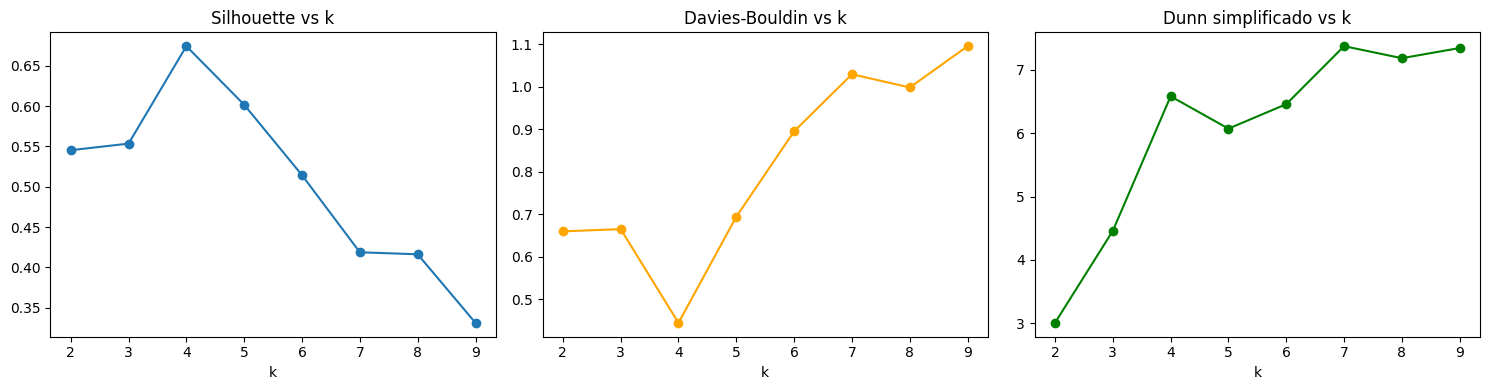

In [6]:
cols_show = [
    "k", "inertia", "cohesion", "separability", "dunn_simple", "dunn_classic", "davies_bouldin", "silhouette"
]
display(df_kmeans[cols_show].round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_kmeans["k"], df_kmeans["silhouette"], marker="o")
axes[0].set_title("Silhouette vs k")
axes[0].set_xlabel("k")

axes[1].plot(df_kmeans["k"], df_kmeans["davies_bouldin"], marker="o", color="orange")
axes[1].set_title("Davies-Bouldin vs k")
axes[1].set_xlabel("k")

axes[2].plot(df_kmeans["k"], df_kmeans["dunn_simple"], marker="o", color="green")
axes[2].set_title("Dunn simplificado vs k")
axes[2].set_xlabel("k")

plt.tight_layout()
plt.show()


Mejor k para blobs (segun silhouette): 4
silhouette        0.674377
davies_bouldin    0.444465
dunn_simple       6.581866
cohesion          0.317238
separability      2.088016
Name: 2, dtype: object


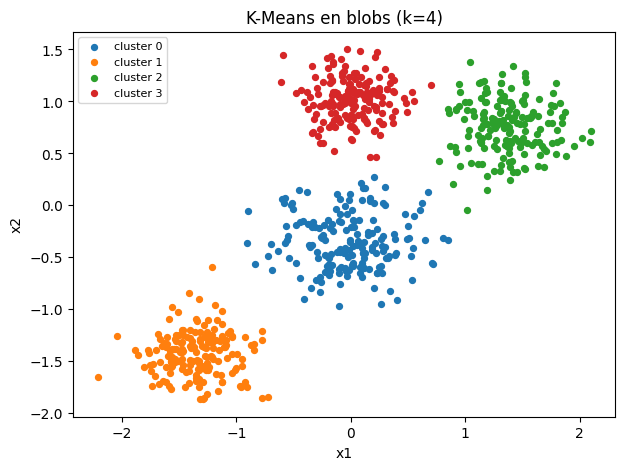

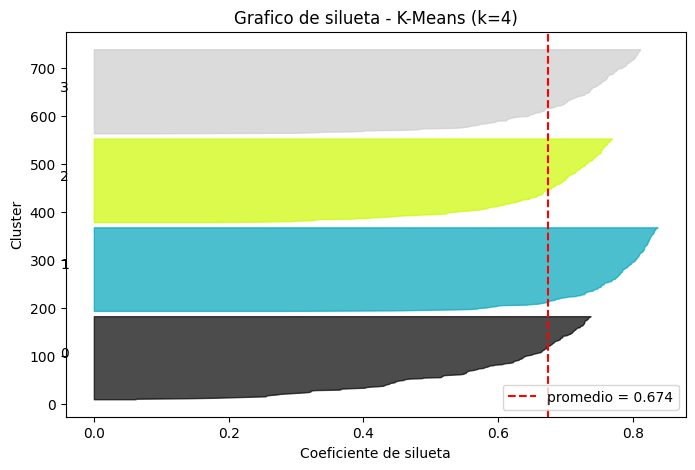

In [7]:
best_k_row = df_kmeans.sort_values(["silhouette", "dunn_simple"], ascending=[False, False]).iloc[0]
best_k = int(best_k_row["k"])
best_k_model, best_k_labels = kmeans_cache[best_k]

print(f"Mejor k para blobs (segun silhouette): {best_k}")
print(best_k_row[["silhouette", "davies_bouldin", "dunn_simple", "cohesion", "separability"]])

plot_clusters(X_blobs_scaled, best_k_labels, title=f"K-Means en blobs (k={best_k})")
plot_silhouette(X_blobs_scaled, best_k_labels, title=f"Grafico de silueta - K-Means (k={best_k})")


## 4. DBSCAN sobre `make_moons + ruido`

Ajustamos `eps` y `min_samples`. Para DBSCAN:
- `eps` controla el radio de vecindad.
- `min_samples` controla la densidad minima para formar cluster.


In [8]:
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons_noise)

eps_values = np.round(np.arange(0.10, 0.41, 0.03), 2)
min_samples_values = [4, 6, 8, 10, 12]

db_rows = []
db_cache = {}

for eps in eps_values:
    for ms in min_samples_values:
        model = DBSCAN(eps=float(eps), min_samples=int(ms))
        labels_db = model.fit_predict(X_moons_scaled)

        row = evaluate_clustering(X_moons_scaled, labels_db, algorithm_name=f"DBSCAN(eps={eps}, min_samples={ms})")
        row["eps"] = float(eps)
        row["min_samples"] = int(ms)
        db_rows.append(row)

        db_cache[(float(eps), int(ms))] = labels_db

df_dbscan = pd.DataFrame(db_rows)
valid_dbscan = df_dbscan[df_dbscan["n_clusters"] >= 2].copy()

# Seleccion pedagogica: evitar soluciones con demasiados micro-clusters o ruido extremo
candidate_dbscan = valid_dbscan[
    (valid_dbscan["noise_ratio"] <= 0.35)
    & (valid_dbscan["n_clusters"].between(2, 6))
].copy()

if len(candidate_dbscan) == 0:
    candidate_dbscan = valid_dbscan.copy()

candidate_dbscan = candidate_dbscan.sort_values(
    ["silhouette", "davies_bouldin", "dunn_simple"],
    ascending=[False, True, False]
)
candidate_dbscan.head(12)


,algorithm,n_clusters,noise_ratio,cohesion,separability,dunn_simple,dunn_classic,davies_bouldin,silhouette,eps,min_samples
12,"DBSCAN(eps=0.16, min_samples=8)",2,0.080519,0.951460,1.862264,1.957269,0.159449,1.021804,0.387532,0.16,8
11,"DBSCAN(eps=0.16, min_samples=6)",2,0.076623,0.954011,1.861502,1.951238,0.159449,1.024936,0.386647,0.16,6
5,"DBSCAN(eps=0.13, min_samples=4)",2,0.089610,0.954887,1.861992,1.949961,0.145744,1.025650,0.385258,0.13,4
18,"DBSCAN(eps=0.19, min_samples=10)",2,0.064935,0.955087,1.855548,1.942805,0.154779,1.029440,0.384500,0.19,10
19,"DBSCAN(eps=0.19, min_samples=12)",2,0.070130,0.955766,1.856666,1.942594,0.154779,1.029551,0.384203,0.19,12
17,"DBSCAN(eps=0.19, min_samples=8)",2,0.063636,0.956392,1.853957,1.938491,0.154779,1.031741,0.383714,0.19,8
24,"DBSCAN(eps=0.22, min_samples=12)",2,0.057143,0.959440,1.851759,1.930042,0.103357,1.036174,0.382117,0.22,12
10,"DBSCAN(eps=0.16, min_samples=4)",2,0.062338,0.957786,1.846972,1.928376,0.137151,1.037088,0.381716,0.16,4
16,"DBSCAN(eps=0.19, min_samples=6)",2,0.055844,0.961799,1.844957,1.918237,0.120619,1.042636,0.379086,0.19,6
20,"DBSCAN(eps=0.22, min_samples=4)",2,0.048052,0.961666,1.844670,1.918203,0.053238,1.042636,0.378665,0.22,4


In [9]:
cols_db = [
    "eps", "min_samples", "n_clusters", "noise_ratio", "cohesion", "separability",
    "dunn_simple", "dunn_classic", "davies_bouldin", "silhouette"
]

display(candidate_dbscan[cols_db].head(15).round(4))

best_db = candidate_dbscan.iloc[0]
best_eps = float(best_db["eps"])
best_ms = int(best_db["min_samples"])
best_db_labels = db_cache[(best_eps, best_ms)]

print(f"Mejor DBSCAN (criterio pedagogico): eps={best_eps}, min_samples={best_ms}")
print(best_db[["n_clusters", "noise_ratio", "silhouette", "davies_bouldin", "dunn_simple"]])


,eps,min_samples,n_clusters,noise_ratio,cohesion,separability,dunn_simple,dunn_classic,davies_bouldin,silhouette
12,0.16,8,2,0.0805,0.9515,1.8623,1.9573,0.1594,1.0218,0.3875
11,0.16,6,2,0.0766,0.9540,1.8615,1.9512,0.1594,1.0249,0.3866
5,0.13,4,2,0.0896,0.9549,1.8620,1.9500,0.1457,1.0256,0.3853
18,0.19,10,2,0.0649,0.9551,1.8555,1.9428,0.1548,1.0294,0.3845
19,0.19,12,2,0.0701,0.9558,1.8567,1.9426,0.1548,1.0296,0.3842
17,0.19,8,2,0.0636,0.9564,1.8540,1.9385,0.1548,1.0317,0.3837
24,0.22,12,2,0.0571,0.9594,1.8518,1.9300,0.1034,1.0362,0.3821
10,0.16,4,2,0.0623,0.9578,1.8470,1.9284,0.1372,1.0371,0.3817
16,0.19,6,2,0.0558,0.9618,1.8450,1.9182,0.1206,1.0426,0.3791
20,0.22,4,2,0.0481,0.9617,1.8447,1.9182,0.0532,1.0426,0.3787


Mejor DBSCAN (criterio pedagogico): eps=0.16, min_samples=8
n_clusters               2
noise_ratio       0.080519
silhouette        0.387532
davies_bouldin    1.021804
dunn_simple       1.957269
Name: 12, dtype: object


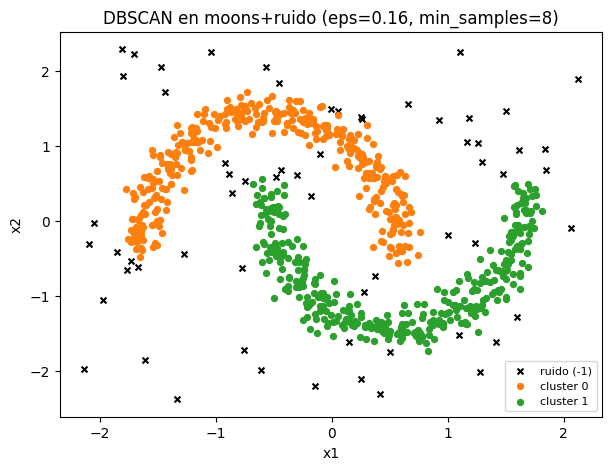

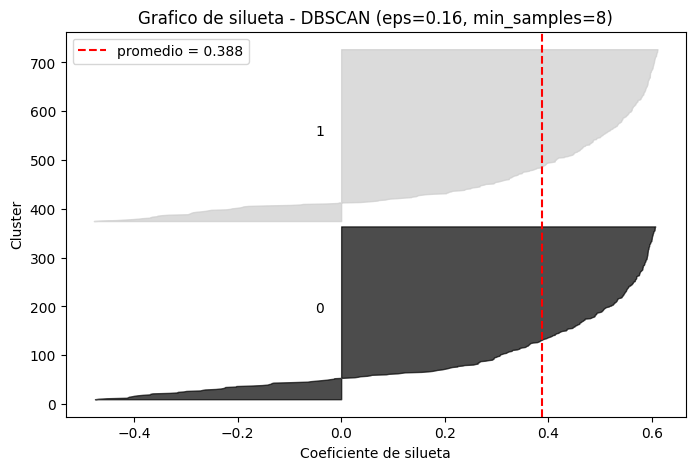

In [10]:
plot_clusters(
    X_moons_scaled,
    best_db_labels,
    title=f"DBSCAN en moons+ruido (eps={best_eps}, min_samples={best_ms})"
)

plot_silhouette(
    X_moons_scaled,
    best_db_labels,
    title=f"Grafico de silueta - DBSCAN (eps={best_eps}, min_samples={best_ms})"
)


## 5. Comparativa directa en dataset no convexo

Comparamos K-Means vs DBSCAN sobre el mismo dataset (`moons + ruido`).


,algorithm,n_clusters,noise_ratio,cohesion,separability,dunn_simple,dunn_classic,davies_bouldin,silhouette
0,KMeans(k=2) en moons,2,0.0000,0.8897,2.0867,2.3454,0.0089,0.8527,0.4735
1,"DBSCAN(eps=0.16, min_samples=8) en moons",2,0.0805,0.9515,1.8623,1.9573,0.1594,1.0218,0.3875


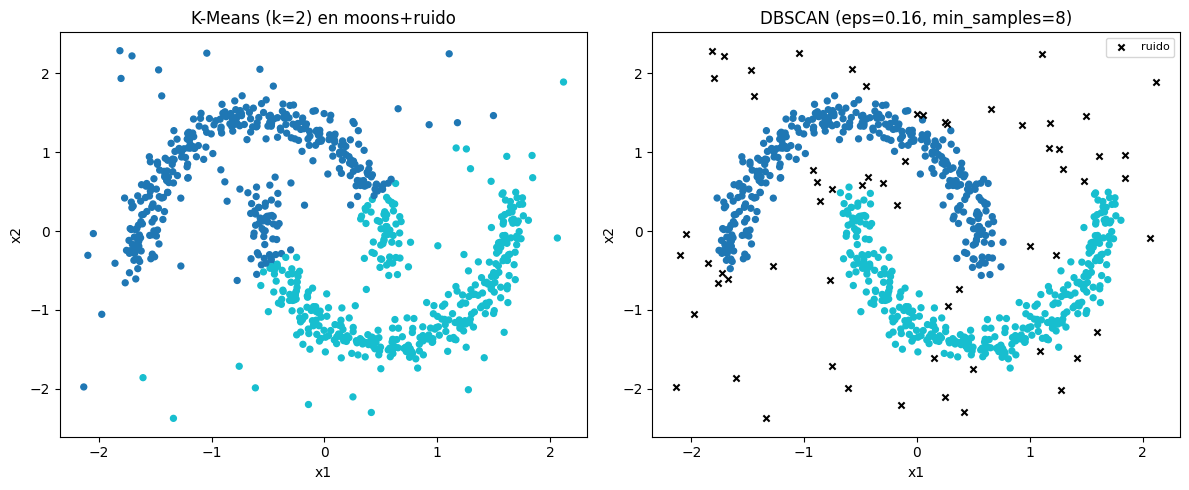

In [11]:
# K-Means forzado con k=2 para moons
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=20)
labels_km_moons = kmeans_moons.fit_predict(X_moons_scaled)

row_km_moons = evaluate_clustering(X_moons_scaled, labels_km_moons, algorithm_name="KMeans(k=2) en moons")
row_db_best = evaluate_clustering(
    X_moons_scaled,
    best_db_labels,
    algorithm_name=f"DBSCAN(eps={best_eps}, min_samples={best_ms}) en moons"
)

df_compare = pd.DataFrame([row_km_moons, row_db_best])
display(df_compare[[
    "algorithm", "n_clusters", "noise_ratio", "cohesion", "separability",
    "dunn_simple", "dunn_classic", "davies_bouldin", "silhouette"
]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=labels_km_moons, s=18, cmap="tab10")
axes[0].set_title("K-Means (k=2) en moons+ruido")

labels_plot = best_db_labels.copy()
axes[1].scatter(X_moons_scaled[labels_plot != -1, 0], X_moons_scaled[labels_plot != -1, 1],
                c=labels_plot[labels_plot != -1], s=18, cmap="tab10")
axes[1].scatter(X_moons_scaled[labels_plot == -1, 0], X_moons_scaled[labels_plot == -1, 1],
                c="black", marker="x", s=20, label="ruido")
axes[1].set_title(f"DBSCAN (eps={best_eps}, min_samples={best_ms})")
axes[1].legend(loc="best", fontsize=8)

for ax in axes:
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()


## 6. Conclusiones didacticas

1. **K-Means** funciona muy bien cuando hay clusters compactos y aproximadamente convexos.
2. **DBSCAN** es fuerte cuando hay formas no convexas y ruido/outliers.
3. Para evaluar clustering, no basta una sola metrica:
   - Cohesion baja,
   - Separabilidad alta,
   - Dunn alto,
   - Davies-Bouldin bajo,
   - Silhouette alto y con grafico estable.
4. El escalado de variables es obligatorio cuando se usan distancias euclidianas.
5. En DBSCAN, reportar porcentaje de ruido (`label = -1`) es clave para interpretar resultados.
